# Lending Club Loan Default Analysis


## Overview

This notebook analyzes personal loan data from Lending Club (LC), one of the 
largest peer-to-peer lending platforms in the United States. Lending Club 
connects borrowers with investors willing to fund their loans — making accurate 
default prediction critical to the platform's financial health and investor returns.

The dataset contains loan records with borrower characteristics captured at the 
time of application, including income, debt levels, employment history, and LC's 
own internal risk grades. Loans are classified as either Fully Paid or Charged Off 
(defaulted), making this a binary classification problem.

## Central Question

**What borrower and loan characteristics are most associated with the likelihood 
of default on a Lending Club personal loan?**

## Hypotheses

1. **Loan Grade** — Loans assigned higher risk grades (E, F, G) will default at 
   significantly higher rates than lower risk grades (A, B), reflecting LC's ability 
   to accurately assess borrower risk upfront.

2. **Debt-to-Income Ratio** — Borrowers with higher DTI ratios will default more 
   frequently, as they carry more existing debt relative to their income and have 
   less financial cushion.

3. **Loan Purpose** — Loans for speculative or open-ended purposes (e.g., small 
   business) will default at higher rates than loans for specific, controlled 
   purchases (e.g., car, wedding).

4. **Home Ownership** — Borrowers with a mortgage will default less frequently 
   than renters, as homeownership signals greater financial stability and 
   demonstrated creditworthiness.

## Approach

The analysis follows three stages:
1. **Data Cleaning** — Handle missing values, remove ambiguous loan statuses, 
   cap outliers, and prepare features for analysis
2. **Exploratory Data Analysis** — Visualize default rates across key borrower 
   and loan characteristics to test our hypotheses
3. **Logistic Regression** — Build a predictive model to identify the strongest 
   drivers of default risk

*Note: FICO score columns were not present in this version of the dataset. 
Interest rate and loan grade serve as effective substitutes, as LC uses credit 
score as a primary input when assigning both.*

## Imports

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

## Data Loading and Preview

We load the Lending Club loan dataset and take an initial look at the structure. 
The raw dataset contains over 100 columns — far more than we need — so our first 
task is identifying which features are actually useful for predicting default.

In [21]:
# load and inspect the data
df = pd.read_csv('loan.csv', low_memory=False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


## Feature Selection

We narrow the dataset down to 18 columns that are directly relevant to our 
analysis questions. Columns were selected based on two criteria: (1) they 
capture meaningful borrower or loan characteristics at origination, and (2) 
they avoid post-origination payment data that would leak information about 
the outcome we're trying to predict.

Columns dropped include payment tracking fields (e.g., `total_pymnt`, `recoveries`), 
joint application fields, and granular credit trade counts that are redundant with 
simpler features like `open_acc` and `revol_util`.

In [22]:
# Cut down the number of columns and focus only on relevant predictors
keep_cols = ['loan_status', 'annual_inc', 'dti', 'loan_amnt', 'int_rate', 'grade', 'inq_last_6mths',
             'home_ownership', 'purpose', 'revol_util', 'delinq_2yrs', 'emp_length',
            'funded_amnt', 'term', 'sub_grade', 'verification_status', 'open_acc', 'pub_rec_bankruptcies']
df = df[keep_cols].copy()
df.head()

,loan_status,annual_inc,dti,loan_amnt,int_rate,grade,inq_last_6mths,home_ownership,purpose,revol_util,delinq_2yrs,emp_length,funded_amnt,term,sub_grade,verification_status,open_acc,pub_rec_bankruptcies
0,Fully Paid,24000.0,27.65,5000,10.65%,B,1,RENT,credit_card,83.70%,0,10+ years,5000,36 months,B2,Verified,3,0.0
1,Charged Off,30000.0,1.00,2500,15.27%,C,5,RENT,car,9.40%,0,< 1 year,2500,60 months,C4,Source Verified,3,0.0
2,Fully Paid,12252.0,8.72,2400,15.96%,C,2,RENT,small_business,98.50%,0,10+ years,2400,36 months,C5,Not Verified,2,0.0
3,Fully Paid,49200.0,20.00,10000,13.49%,C,1,RENT,other,21%,0,10+ years,10000,36 months,C1,Source Verified,10,0.0
4,Current,80000.0,17.94,3000,12.69%,B,0,RENT,other,53.90%,0,1 year,3000,60 months,B5,Source Verified,15,0.0


## Data Preparation and Cleaning

Before analyzing the data, we need to do a few things:

1. **Filter loan_status** — We keep only "Fully Paid" and "Charged Off" loans. 
   Other statuses like "Current" or "In Grace Period" have unknown outcomes and 
   would muddy the analysis.
2. **Create a binary target** — "Charged Off" (defaulted) becomes 1, "Fully Paid" becomes 0.
3. **Convert percentage strings** — `int_rate` and `revol_util` are stored as strings 
   with "%" symbols and need to be converted to floats.
4. **Rename columns** — We rename several columns for readability.
    

In [23]:
# Clean up loan_status. We only want Fully Paid and Charged Off status for loan, so we
# need to remove all other rows besides these two.
df['loan_status'] = df['loan_status'].str.strip()
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Change loan_status to default where Charged Off is 1, and Fully Paid is 0
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

# Change type of interest rate from % to float
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)
df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '').astype(float)

# Change columns names for readability
df = df.rename(columns={'dti':'debt_to_income_ratio', 'annual_inc':'annual_income', 'int_rate':'interest_rate',
                       'emp_length':'employment_length', 'funded_amnt':'funded_amount', 'term':'loan_term',
                       'open_acc':'num_accounts_open', 'inq_last_6mths':'num_inquiries_last_6months',
                       'pub_rec_bankruptcies':'public_record_bankruptcies', 'loan_amnt':'loan_amount',
                       'revol_util':'credit_utilization_rate', 'delinq_2yrs':'delinquencies_2years'})

print(f'Shape of the dataframe is: {df.shape}')
print(df['default'].value_counts())


Shape of the dataframe is: (38577, 19)
0    32950
1     5627
Name: default, dtype: int64


Out of the 38,577 loans in our filtered dataset, 32,950 are Fully Paid (0) 
and 5,627 are Charged Off (1). Defaulted loans account for roughly 14.5% of 
the data — a meaningful class imbalance that we'll need to account for later 
when building our model.

## Null Value Analysis

We check each column for missing values. Only columns with at least one null 
are displayed. Low null percentages (under 5%) are generally safe to impute 
rather than drop.

In [24]:
# See null counts and percentage
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
display(null_summary[null_summary['null_count'] > 0])

,null_count,null_pct
credit_utilization_rate,50,0.13
employment_length,1033,2.68
public_record_bankruptcies,697,1.81


Only three columns had null values — all at low percentages (under 3%), 
which is well within an acceptable range for imputation. Here's how we handle each:

- **employment_length** — This is a categorical field. A missing value here 
  likely means the applicant didn't report employment, so we fill with `'Unknown'` 
  rather than guessing.
- **credit_utilization_rate** — A continuous rate, so we impute the median. 
  We use median rather than mean because outliers in utilization would skew the mean.
- **public_record_bankruptcies** — A missing value here most plausibly means 
  no bankruptcy on record (if there were one, it would almost certainly have been 
  captured). We will fill with 0.

## Null Value Treatment

In [25]:
# Handle null values. Fill in Unknown for employment_length
# Impute median for credit_utilization_rate
# Replace na in public_record_bankruptcies to 0, assuming no bankruptcies on file

df['employment_length'] = df['employment_length'].fillna('Unknown')
df['credit_utilization_rate'] = df['credit_utilization_rate'].fillna(df['credit_utilization_rate'].median())
df['public_record_bankruptcies'] = df['public_record_bankruptcies'].fillna(0)

print(df.shape)

# Confirm no more NaN values in df
print(df.isnull().sum().sum())

(38577, 19)
0


In [26]:
# check for outliers and visualize the data
df.describe()

,annual_income,debt_to_income_ratio,loan_amount,interest_rate,num_inquiries_last_6months,credit_utilization_rate,delinquencies_2years,funded_amount,num_accounts_open,public_record_bankruptcies,default
count,3.857700e+04,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000
mean,6.877797e+04,13.272727,11047.025430,11.932219,0.871737,48.703292,0.146668,10784.058506,9.275423,0.042694,0.145864
std,6.421868e+04,6.673044,7348.441646,3.691327,1.071546,28.346356,0.492271,7090.306027,4.401588,0.202809,0.352975
min,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,500.000000,2.000000,0.000000,0.000000
25%,4.000000e+04,8.130000,5300.000000,8.940000,0.000000,25.200000,0.000000,5200.000000,6.000000,0.000000,0.000000
50%,5.886800e+04,13.370000,9600.000000,11.710000,1.000000,49.100000,0.000000,9550.000000,9.000000,0.000000,0.000000
75%,8.200000e+04,18.560000,15000.000000,14.380000,1.000000,72.200000,0.000000,15000.000000,12.000000,0.000000,0.000000
max,6.000000e+06,29.990000,35000.000000,24.400000,8.000000,99.900000,11.000000,35000.000000,44.000000,2.000000,1.000000


A few things stand out worth investigating:

- **annual_income** — The max is 6,000,000 while the median is just under 59,000. 
  That's a significant gap, and a handful of ultra-high earners could skew our analysis.
- **delinquencies_2years** — Max of 11 against a median of 0. Most borrowers have 
  no recent delinquencies, so the distribution is heavily right-skewed.
- **num_accounts_open** — Max of 44 against a median of 9. Plausible but worth visualizing.

We'll use boxplots to get a clearer picture before deciding how to handle these.

## Outlier Visualization

Boxplots give us a quick visual check on the distribution of each numeric feature. 
The box represents the interquartile range (IQR), the line inside is the median, 
and dots beyond the whiskers are statistical outliers.

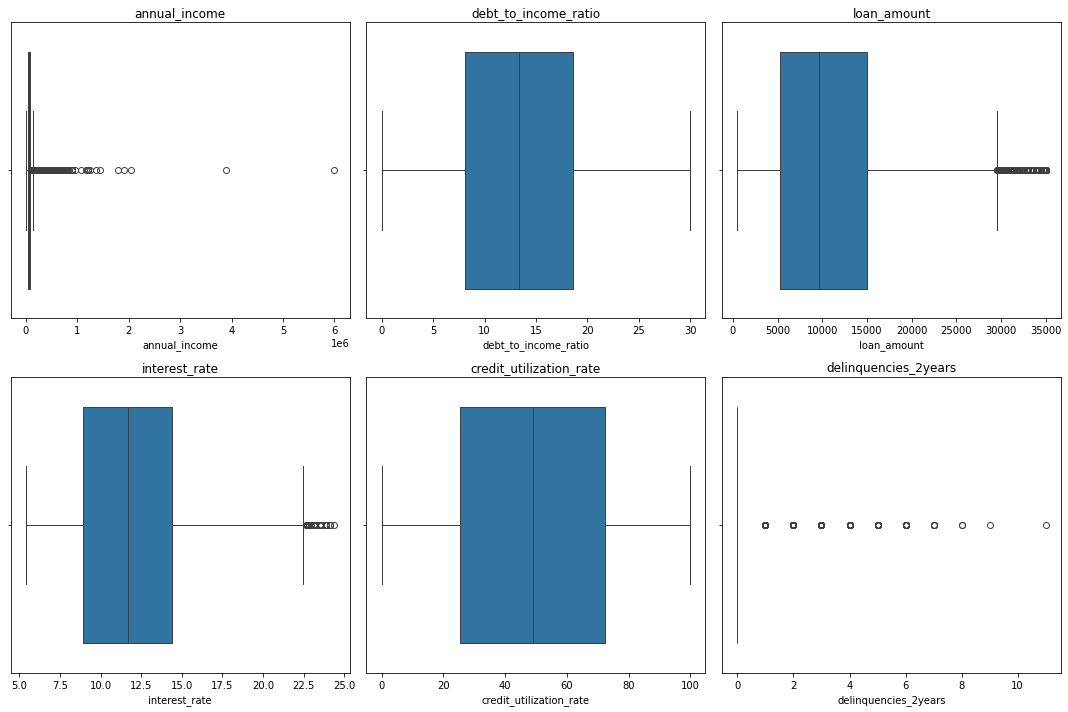

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols = ['annual_income', 'debt_to_income_ratio', 'loan_amount', 
        'interest_rate', 'credit_utilization_rate', 'delinquencies_2years']

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Most distributions look reasonable — the boxes and whiskers are proportional and 
there are no alarming extremes in DTI, interest rate, or credit utilization.

Two observations stand out:

- **annual_income** — The entire box is crammed to the left side of the plot, with 
  outliers stretching far to the right. The $4M–$6M earners are visually dominating 
  the scale. We'll cap this at the 99th percentile to bring it back into a range 
  that reflects the typical borrower.
- **delinquencies_2years** — There's no visible box at all, just floating dots. 
  This is expected — the median and IQR are essentially zero since most borrowers 
  have no delinquencies. The dots are legitimate high-delinquency outliers, but 
  because this is a count variable (not a continuous rate), capping isn't appropriate. 
  We will leave it as-is.

## Outlier Treatment

Based on the boxplots, only `annual_income` needs to be capped. We use the 99th 
percentile as our ceiling — this keeps the high-earning borrowers in the dataset 
while removing the distorting effect of the extreme outliers. Dropping them 
entirely would introduce bias; capping preserves the observation while bounding 
its influence.

In [28]:
cap = df['annual_income'].quantile(0.99)
df['annual_income'] = df['annual_income'].clip(upper=cap)

df.describe()

,annual_income,debt_to_income_ratio,loan_amount,interest_rate,num_inquiries_last_6months,credit_utilization_rate,delinquencies_2years,funded_amount,num_accounts_open,public_record_bankruptcies,default
count,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000
mean,67002.920573,13.272727,11047.025430,11.932219,0.871737,48.703292,0.146668,10784.058506,9.275423,0.042694,0.145864
std,38801.725311,6.673044,7348.441646,3.691327,1.071546,28.346356,0.492271,7090.306027,4.401588,0.202809,0.352975
min,4000.000000,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,500.000000,2.000000,0.000000,0.000000
25%,40000.000000,8.130000,5300.000000,8.940000,0.000000,25.200000,0.000000,5200.000000,6.000000,0.000000,0.000000
50%,58868.000000,13.370000,9600.000000,11.710000,1.000000,49.100000,0.000000,9550.000000,9.000000,0.000000,0.000000
75%,82000.000000,18.560000,15000.000000,14.380000,1.000000,72.200000,0.000000,15000.000000,12.000000,0.000000,0.000000
max,234144.000000,29.990000,35000.000000,24.400000,8.000000,99.900000,11.000000,35000.000000,44.000000,2.000000,1.000000


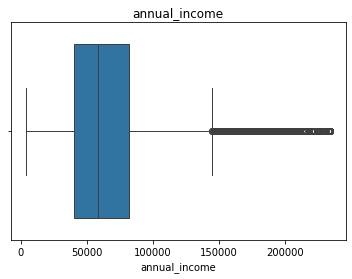

In [29]:
# replot annual income box and whisker to show distribution after capping at 99th percentile
sns.boxplot(x=df['annual_income'])
plt.title('annual_income')
plt.show()

Much better. The box is now visible and the whisker extends rightward to the capped 
ceiling, where you can see the clustered values bunching at the 99th percentile. 
Income data is inherently right-skewed in the real world, so a leftward box is 
expected — this distribution is now clean enough to work with.

---

## Exploratory Data Analysis

With our data cleaned, we move into EDA — testing each of our four hypotheses 
through visualization. Each chart is designed to directly address one of the 
questions we set out to answer.

### Hypothesis 1: Default Rate by Loan Grade

Lending Club assigns grades A through G based on the borrower's overall 
creditworthiness at origination. Grade A represents the lowest-risk borrowers 
(high credit score, low DTI, stable employment) and gets the lowest interest rates, 
while Grade G represents the highest-risk borrowers and carries rates exceeding 24%.

If LC's grading system is effective, we'd expect a clear and consistent step-up 
in default rates from A to G.

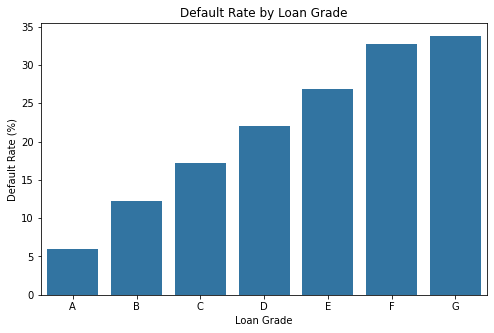

In [30]:
# Default rate by loan grade
grade_default = df.groupby('grade')['default'].mean().reset_index()
grade_default['default_rate'] = grade_default['default'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=grade_default, x='grade', y='default_rate', order=['A','B','C','D','E','F','G'])
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.show()

Textbook result — a clean A-to-G progression with no exceptions. Every grade 
defaults more than the one before it, confirming that LC's internal risk 
assessment aligns well with actual borrower outcomes.

One detail worth noting: the gap between F and G is smaller than the gaps 
earlier in the scale. This is likely because F and G loans are rare in the 
dataset, making those estimates less statistically stable.

**Hypothesis 1: Confirmed.** Loan grade is a strong categorical predictor 
of default, with Grade G borrowers defaulting at roughly 6x the rate of Grade A.

### Hypothesis 2: Default Rate by Loan Purpose

Borrowers report the intended use of their loan at application. We're testing 
whether loan purpose carries predictive signal — specifically, whether 
speculative or open-ended purposes (like small business funding) default at 
higher rates than targeted purchases (like a car or wedding).

,purpose,default,default_rate
11,small_business,0.270810,27.080958
10,renewable_energy,0.186275,18.627451
3,educational,0.172308,17.230769
9,other,0.163777,16.377749
5,house,0.160763,16.076294
8,moving,0.159722,15.972222
7,medical,0.155653,15.565345
2,debt_consolidation,0.153254,15.325395
12,vacation,0.141333,14.133333
4,home_improvement,0.120696,12.069565


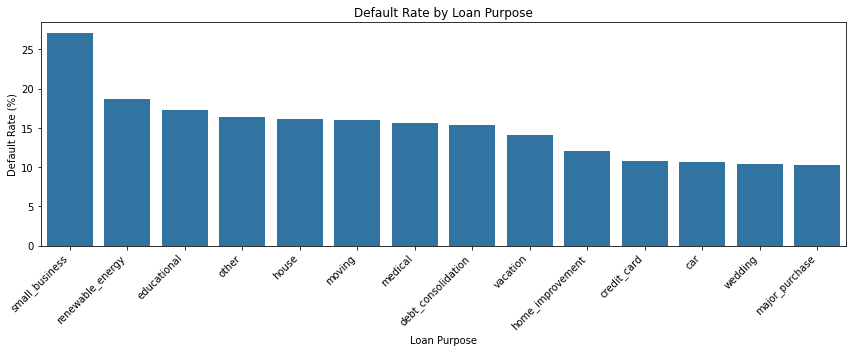

In [31]:
purpose_default = df.groupby('purpose')['default'].mean().reset_index()
purpose_default['default_rate'] = purpose_default['default'] * 100
purpose_default = purpose_default.sort_values('default_rate', ascending=False)
display(purpose_default)

plt.figure(figsize=(12, 5))
sns.barplot(data=purpose_default, x='purpose', y='default_rate')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Small business loans default at nearly 27% — almost double the next highest 
category. This makes intuitive sense: personal loans used to fund businesses 
carry entrepreneurial risk on top of personal credit risk. If the business 
fails, the borrower loses both the income stream they were counting on and 
the ability to repay.

On the other end, car and credit card loans default at roughly 10-11%. Borrowers 
with a specific, tangible use for the money tend to be more disciplined repayers.

**Hypothesis 2: Confirmed.** Loan purpose is a meaningful predictor of default, 
with small business loans carrying substantially elevated risk.

### Hypothesis 3: DTI Distribution — Defaulted vs. Fully Paid

We compare the debt-to-income ratio distributions for defaulted and fully paid 
borrowers. Rather than using raw counts (which would make the smaller defaulted 
group hard to see), we normalize both distributions so we're comparing shape — 
not volume.

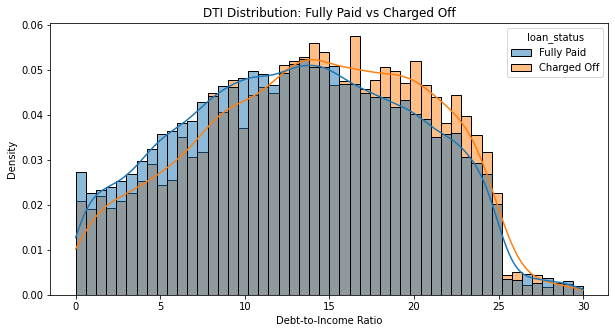

In [32]:
# Normalize the data with stat='density' and common_norm=False so we can compare the shape of distribution
# versus raw counts. There are significantly more Fully Paid loans versus Charged Off
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='debt_to_income_ratio', hue='loan_status',
             bins=50, kde=True, alpha=0.5, stat='density', common_norm=False)
plt.title('DTI Distribution: Fully Paid vs Charged Off')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Density')
plt.show()

Borrowers who defaulted tend to have higher debt-to-income ratios than those who fully repaid their loans. The Charged Off distribution is shifted right relative to the Fully Paid distribution, suggesting that carrying more existing debt relative to income is associated with a higher likelihood of default. This aligns with intuition — borrowers already stretched thin financially are less able to absorb unexpected financial shocks.

**Hypothesis 3: Confirmed.** Higher DTI is associated with higher default risk.

### Hypothesis 4: Default Rate by Home Ownership

We test whether homeownership status carries predictive signal. Our hypothesis 
is that borrowers with a mortgage will default least, as qualifying for a home 
loan requires demonstrated creditworthiness that likely extends to personal 
loan behavior.

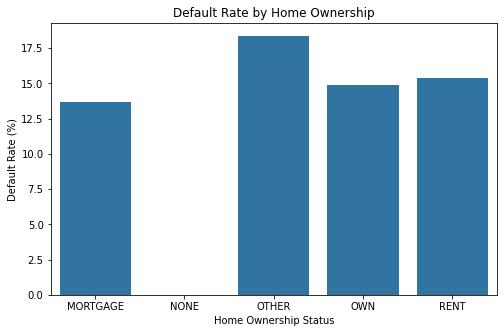

In [33]:
home_default = df.groupby('home_ownership')['default'].mean().reset_index()
home_default['default_rate'] = home_default['default'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=home_default, x='home_ownership', y='default_rate')
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership Status')
plt.ylabel('Default Rate (%)')
plt.show()

In [34]:
display(home_default.sort_values('default_rate', ascending=False))

,home_ownership,default,default_rate
2,OTHER,0.183673,18.367347
4,RENT,0.153626,15.362554
3,OWN,0.148908,14.890756
0,MORTGAGE,0.136713,13.671347
1,NONE,0.000000,0.000000


The results are interesting — and partially counterintuitive. Borrowers with 
a mortgage default least at 13.7%, even though they carry an additional monthly 
payment. The likely explanation: getting approved for a mortgage signals that 
a lender has already vetted you, which correlates with the kind of financial 
discipline that predicts loan repayment generally.

Renters and outright owners default at similar rates (~15%), while the "Other" 
category is highest at 18.4% — possibly capturing borrowers in unstable or 
unconventional housing situations that signal financial instability.

The "None" category shows a 0% default rate but should be disregarded — it 
contains very few records and isn't statistically meaningful.

**Hypothesis 4: Partially Confirmed.** Home ownership status carries modest 
predictive signal, with mortgage holders defaulting least — though the differences 
are smaller than with grade or purpose.

---

## Correlation Analysis

We examine pairwise correlations between our numeric features and the default 
target. This gives us a sense of which individual variables carry the strongest 
linear relationship with default.

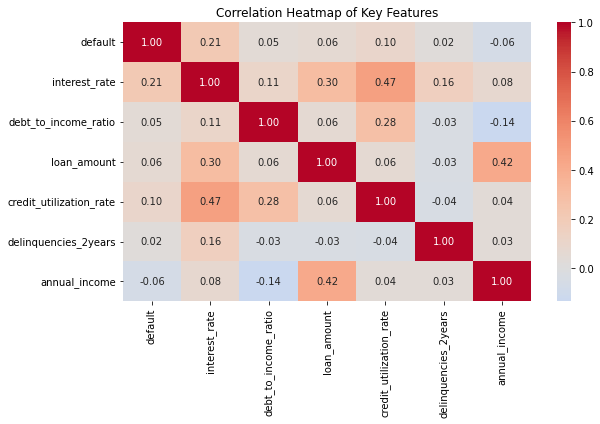

In [35]:
corr_cols = ['default', 'interest_rate', 'debt_to_income_ratio', 
             'loan_amount', 'credit_utilization_rate', 
             'delinquencies_2years', 'annual_income']

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.show()

Interest rate is the strongest individual numeric predictor of default (r = 0.21), 
which is consistent with our grade findings — both are downstream of LC's internal 
risk assessment and both encode similar information about borrower risk.

Annual income shows a slight negative correlation (-0.06), meaning higher earners 
default marginally less — though the relationship is not strong.

The most notable takeaway is that none of the individual correlations are 
particularly strong. This isn't a failure of the data — it reflects a real 
characteristic of credit risk: default is driven by a combination of factors, 
not dominated by any single one. That's what makes the logistic regression 
step useful.

One additional observation: interest rate and credit utilization are correlated 
with each other (r = 0.47), meaning LC tends to charge higher rates to borrowers 
who are already using more of their available credit — a sensible risk pricing signal.

---

# Logistic Regression Modeling

With EDA complete, we move to modeling. Our target is binary (default vs. no default), so a logistic regression model will fit here. The features are a mix  of numeric and categorical variables, and the model outputs interpretable  probabilities that map cleanly to credit risk.

We will encode all categorical columns using one-hot encoding, scale the numeric features with StandardScaler, and use an 80/20 train/test split.

### Initial Model

In [36]:
# Encode categorical columns
df_model = pd.get_dummies(df, columns=['grade', 'sub_grade', 'purpose', 'home_ownership', 
                                        'verification_status', 'employment_length', 
                                        'loan_term'], drop_first=True)

# Define features and target
drop_cols = ['loan_status', 'default']
X = df_model.drop(columns=drop_cols)
y = df_model['default']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6621
           1       0.50      0.02      0.03      1095

    accuracy                           0.86      7716
   macro avg       0.68      0.51      0.48      7716
weighted avg       0.81      0.86      0.80      7716



## Issue: Class Imbalance

The initial model achieves 86% accuracy — but that number is misleading. 
With a Class 1 recall of just 0.02, it correctly identifies only 2% of actual 
defaults, meaning it misses 98% of the borrowers most likely to default.

This is a classic class imbalance problem. Because ~85% of loans are Fully Paid, 
the model learns that predicting "Fully Paid" for everyone is a winning strategy 
without ever learning what actually makes a borrower risky.

In a real lending context, this model would be essentially useless. Missing 98% 
of defaults means approving almost every high-risk loan as if it were safe — 
exactly the behavior we're trying to avoid.

We fix this by adding `class_weight='balanced'`, which penalizes the model more 
heavily for missing a default than for incorrectly flagging a good borrower. 
This forces the model to actually learn the characteristics of the minority class.

### Balanced Model

In [37]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76      6621
           1       0.23      0.64      0.34      1095

    accuracy                           0.65      7716
   macro avg       0.57      0.64      0.55      7716
weighted avg       0.82      0.65      0.70      7716



## Interpretation: Comparing Both Models

| Metric | Initial Model | Balanced Model |
|--------|--------------|----------------|
| Overall Accuracy | 86% | 65% |
| Default Recall (Class 1) | 0.02 | 0.64 |
| Non-Default Recall (Class 0) | 1.00 | 0.65 |

The balanced model trades raw accuracy (86% down to 65%) for a dramatic improvement 
in actually finding defaulters. Default recall jumps from 2% to 64%, 
meaning the model now catches nearly two-thirds of actual defaults instead of 
almost none.

The tradeoff is that precision on defaults drops to 0.23 — the model flags some 
good borrowers as risky. In a real lending context, that's a sensible tradeoff: 
missing a default is far more costly than wrongly declining a creditworthy applicant.

In practice, a lender would tune the classification threshold based on their 
specific risk tolerance — accepting more false positives (rejected good borrowers) 
in exchange for catching more true defaults.

## Conclusions

This analysis set out to answer a central question: what borrower and loan 
characteristics are most associated with default risk on Lending Club personal loans?

### Key Findings

**Loan Grade is the strongest categorical predictor of default.** Default rates 
increase consistently from Grade A (~5%) to Grade G (~30%), confirming that LC's 
internal risk assessment system effectively captures borrower risk. This makes 
intuitive sense as grade directly incorporates credit history, income, and debt burden.

**Loan purpose matters significantly.** Small business loans default at nearly 27%, 
almost double the next highest category. Borrowers using personal loans to fund 
businesses carry substantially more risk than those consolidating debt or financing 
a specific purchase like a car or wedding.

**Debt-to-income ratio is a meaningful signal.** Defaulted borrowers show a 
rightward shift in DTI distribution compared to fully paid borrowers, confirming 
that borrowers already stretched thin financially are less able to absorb unexpected 
financial shocks.

**Home ownership provides a modest signal.** Borrowers with mortgages default least 
(13.7%), likely because qualifying for a mortgage requires demonstrated 
creditworthiness. Borrowers in the "Other" category default most (18.4%).

**Interest rate is the strongest individual numeric predictor** (r=0.21 with default), 
which aligns with the grade findings since LC sets rates based on its own risk assessment.

### Modeling

A logistic regression model with class imbalance correction achieved 64% recall on 
defaulted loans, correctly identifying nearly two thirds of actual defaults. While 
overall accuracy dropped compared to the naive model, this represents a far more 
useful tool for real-world risk assessment where missing a default carries 
significant financial consequences.

### Limitations

- This dataset represents a snapshot of LC loans and may not generalize to other 
  lenders or time periods
- FICO score data was unavailable in this version of the dataset, which may have 
  improved model performance
- A more sophisticated model (Random Forest, XGBoost) would likely outperform 
  logistic regression on this type of structured financial data

### Final Takeaway

Default risk is best understood as a combination of factors rather than any single 
variable. Loan grade, purpose, and DTI together paint a clearer picture of borrower 
risk than any individual feature alone.